In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

In [7]:
# 1. LOAD DATA

df = pd.read_csv("Hotel_bookings_final.csv")

print("Shape of Dataset:", df.shape)
df.head()

Shape of Dataset: (30000, 24)


,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,...,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,...,25342,PayPal,Yes,369.648995,Web,Confirmed,2024-03-04,5.374694,0.000000,No
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,...,8033,Bank Transfer,Yes,492.505903,Web,Confirmed,2024-07-19,7.161033,0.000000,No
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,...,29715,Debit Card,Yes,0.000000,iOS,Confirmed,2024-03-22,0.000000,0.000000,No
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,...,44592,Bank Transfer,Yes,545.541516,Android,Confirmed,2024-11-24,7.932170,24.500442,Yes
4,40,5,Seattle,5,2024-04-01,NaN,NaN,Deluxe,1,Leisure,...,15873,Debit Card,Yes,211.367602,Web,Cancelled,2024-03-02,0.000000,0.000000,No


In [9]:
# 2. DATA UNDERSTANDING

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())


Data Types
customer_id             int64
property_id             int64
city                   object
star_rating             int64
booking_date           object
check_in_date          object
check_out_date         object
room_type              object
num_rooms_booked        int64
stay_type              object
booking_channel        object
booking_value         float64
costprice               int64
markup                  int64
selling_price           int64
payment_method         object
refund_status          object
refund_amount         float64
channel_of_booking     object
booking_status         object
travel_date            object
cashback              float64
coupon_redeem         float64
Coupon USed?           object
dtype: object

Missing Values
customer_id              0
property_id              0
city                     0
star_rating              0
booking_date             0
check_in_date         5468
check_out_date        5468
room_type                0
num_rooms_booked      

In [11]:
# 3. DATA CLEANING

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert date columns
date_cols = ['booking_date','check_in_date','check_out_date']

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

# Stay Length
df['stay_length'] = (
    df['check_out_date'] - df['check_in_date']
).dt.days

# Booking Lead Time
df['lead_time'] = (
    df['check_in_date'] - df['booking_date']
).dt.days

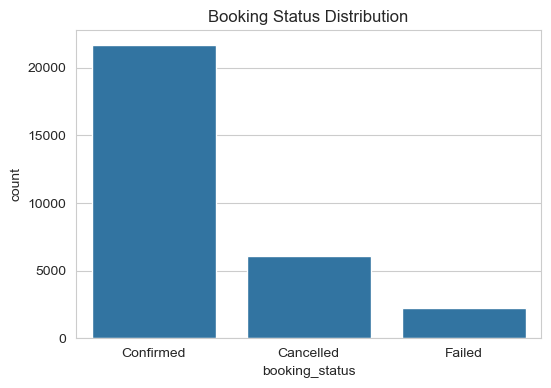

booking_status
Confirmed    21672
Cancelled     6070
Failed        2258
Name: count, dtype: int64
Cancellation Rate: 20.23%


In [13]:
# 4. OVERALL BOOKING STATUS

booking_status = df['booking_status'].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(data=df,x='booking_status')
plt.title("Booking Status Distribution")
plt.show()

print(booking_status)

# Cancellation Rate
cancel_rate = (
    (df['booking_status']=='Cancelled').mean()*100
)

print(f"Cancellation Rate: {cancel_rate:.2f}%")

  channel_of_booking  total_bookings  avg_booking_value
0            Android            9505       25355.242358
1                Web           16023       24973.016853
2                iOS            4472       24881.828258


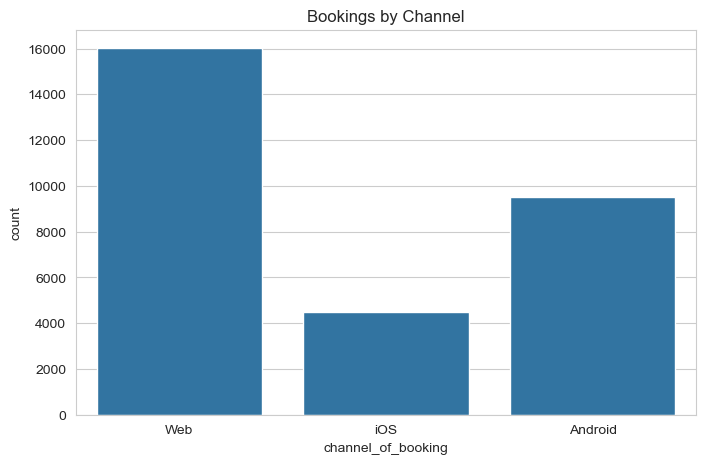

booking_status      Cancelled  Confirmed    Failed
channel_of_booking                                
Android             20.000000  72.330352  7.669648
Web                 20.333271  72.077638  7.589091
iOS                 20.371199  72.629696  6.999106


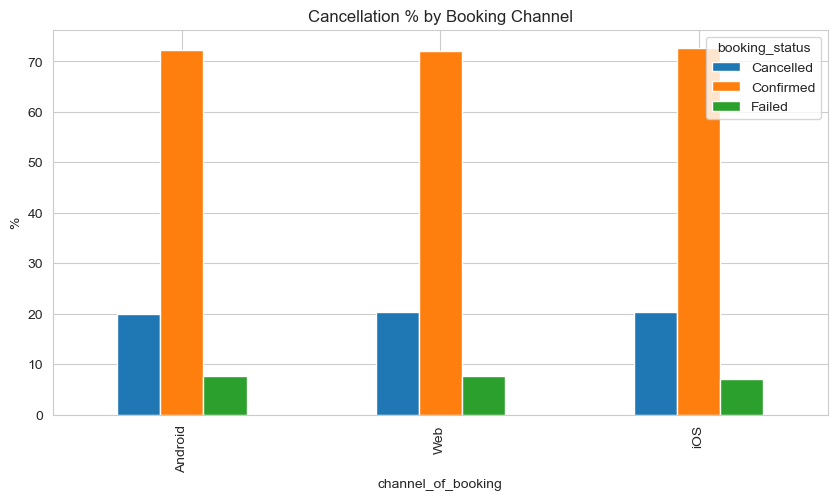

In [19]:
# 5. BOOKING CHANNEL ANALYSIS

channel_booking = (
    df.groupby('channel_of_booking')
      .agg(
          total_bookings=('channel_of_booking', 'size'),
          avg_booking_value=('booking_value', 'mean')
      )
      .reset_index()
)

print(channel_booking)

plt.figure(figsize=(8,5))
sns.countplot(data=df,x='channel_of_booking')
plt.title("Bookings by Channel")
plt.show()

# Cancellation by Channel

channel_cancel = pd.crosstab(
    df['channel_of_booking'],
    df['booking_status'],
    normalize='index')*100

print(channel_cancel)

channel_cancel.plot(kind='bar')
plt.title("Cancellation % by Booking Channel")
plt.ylabel("%")
plt.show()

  room_type  total_bookings  avg_booking_value  avg_stay_length
0    Deluxe           10478       25004.565025         4.025992
1  Standard           16552       25146.970413         3.998863
2     Suite            2970       24978.207751         3.982436


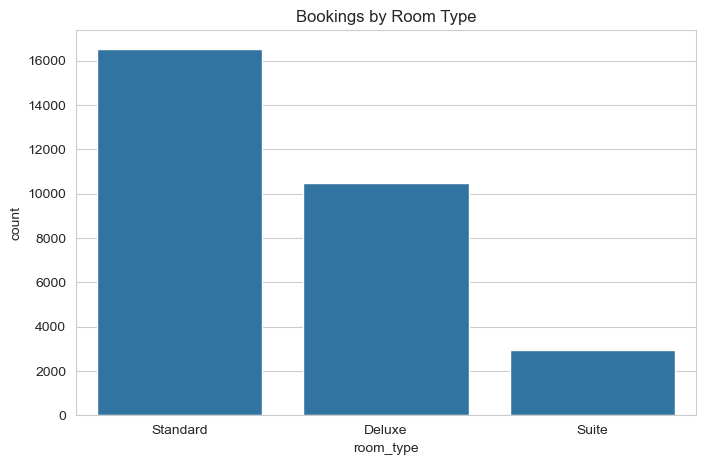

booking_status  Cancelled  Confirmed    Failed
room_type                                     
Deluxe          16.024050  76.312273  7.663676
Standard        23.302320  69.188014  7.509667
Suite           17.979798  74.882155  7.138047


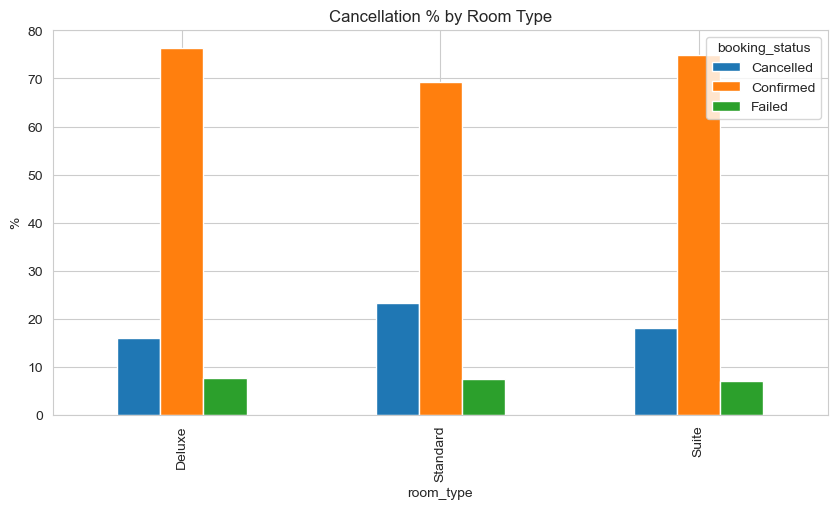

In [25]:
# 6. ROOM TYPE ANALYSIS

room_analysis = (
    df.groupby('room_type')
      .agg(
          total_bookings=('room_type', 'size'),
          avg_booking_value=('booking_value', 'mean'),
          avg_stay_length=('stay_length', 'mean')
      )
      .reset_index()
)

print(room_analysis)

plt.figure(figsize=(8,5))
sns.countplot(data=df,x='room_type')
plt.title("Bookings by Room Type")
plt.show()

# Cancellation by Room Type

room_cancel = pd.crosstab(
    df['room_type'],
    df['booking_status'],
    normalize='index'
)*100

print(room_cancel)

room_cancel.plot(kind='bar')
plt.title("Cancellation % by Room Type")
plt.ylabel("%")
plt.show()

   star_rating  total_bookings  avg_booking_value  avg_stay_length
0            2            2995       24855.819716         4.038509
1            3           10460       25209.567736         4.018277
2            4           12034       25010.623536         3.992093
3            5            4511       25116.972161         3.998625


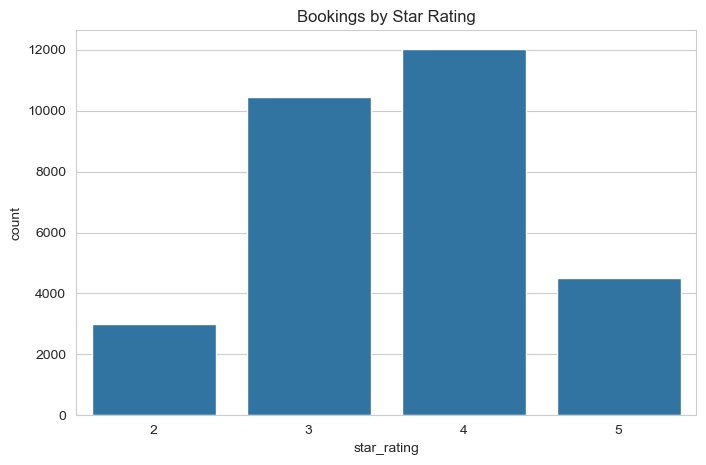

booking_status  Cancelled  Confirmed    Failed
star_rating                                   
2               19.766277  72.854758  7.378965
3               20.200765  72.648184  7.151052
4               19.993352  72.112348  7.894299
5               21.259144  71.225892  7.514963


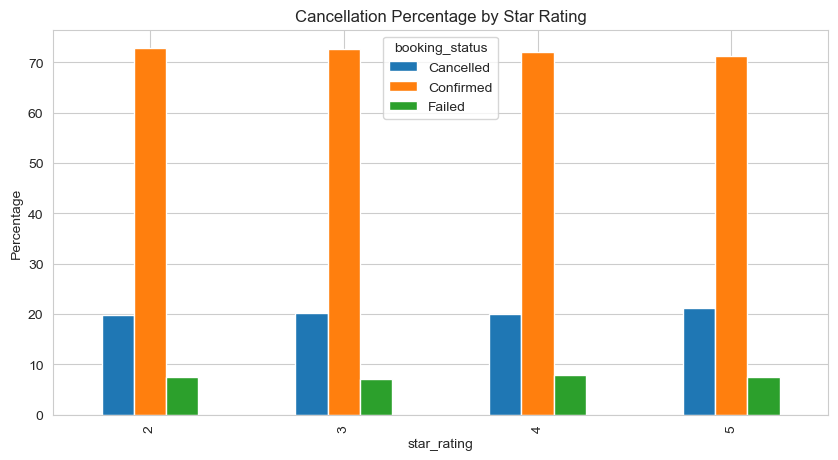

In [27]:
# 7. STAR RATING ANALYSIS

star_analysis = (
    df.groupby('star_rating')
      .agg(
          total_bookings=('customer_id','count'),
          avg_booking_value=('booking_value','mean'),
          avg_stay_length=('stay_length','mean')
      )
      .reset_index()
)

print(star_analysis)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='star_rating')
plt.title("Bookings by Star Rating")
plt.show()

# Cancellation by Star Rating

star_cancel = pd.crosstab(
    df['star_rating'],
    df['booking_status'],
    normalize='index'
)*100

print(star_cancel)

star_cancel.plot(kind='bar')
plt.title("Cancellation Percentage by Star Rating")
plt.ylabel("Percentage")
plt.show()

  channel_of_booking  total_bookings  avg_booking_value
0            Android            9505       25355.242358
1                Web           16023       24973.016853
2                iOS            4472       24881.828258


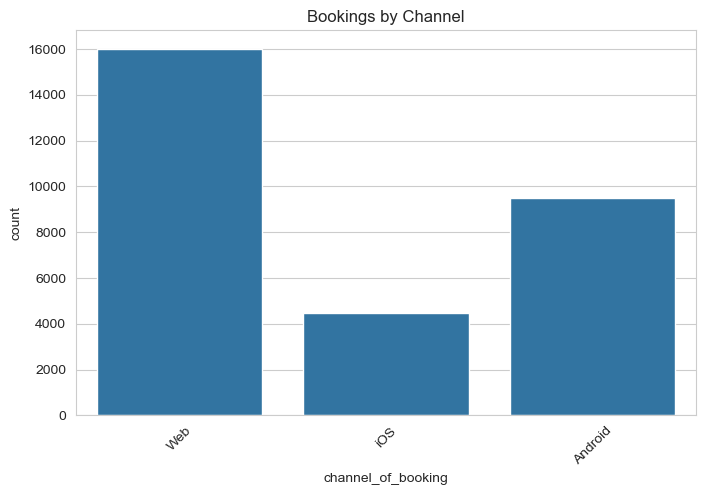

booking_status      Cancelled  Confirmed    Failed
channel_of_booking                                
Android             20.000000  72.330352  7.669648
Web                 20.333271  72.077638  7.589091
iOS                 20.371199  72.629696  6.999106


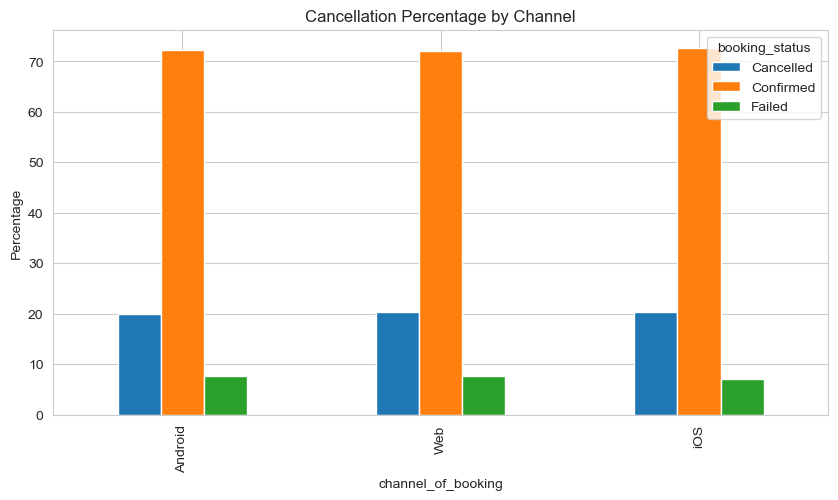

In [29]:
# 8. BOOKING CHANNEL ANALYSIS

channel_analysis = (
    df.groupby('channel_of_booking')
      .agg(
          total_bookings=('customer_id','count'),
          avg_booking_value=('booking_value','mean')
      )
      .reset_index()
)

print(channel_analysis)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='channel_of_booking')
plt.title("Bookings by Channel")
plt.xticks(rotation=45)
plt.show()

# Cancellation by Channel

channel_cancel = pd.crosstab(
    df['channel_of_booking'],
    df['booking_status'],
    normalize='index'
)*100

print(channel_cancel)

channel_cancel.plot(kind='bar')
plt.title("Cancellation Percentage by Channel")
plt.ylabel("Percentage")
plt.show()

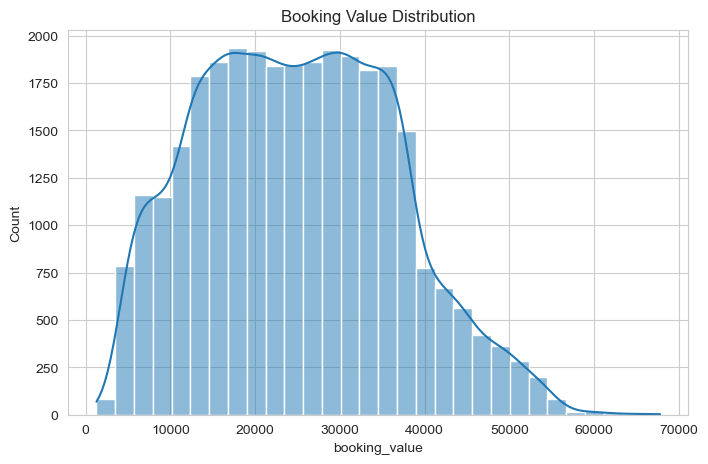

count    30000.000000
mean     25080.525454
std      11587.369335
min       1279.770000
25%      15922.712500
50%      24736.145000
75%      33570.000000
max      67764.460000
Name: booking_value, dtype: float64


In [31]:
# 9. BOOKING VALUE ANALYSIS

plt.figure(figsize=(8,5))
sns.histplot(df['booking_value'], bins=30, kde=True)
plt.title("Booking Value Distribution")
plt.show()

print(df['booking_value'].describe())

channel_of_booking
Android    7004.273540
Web        6946.835799
iOS        6935.367174
Name: profit, dtype: float64


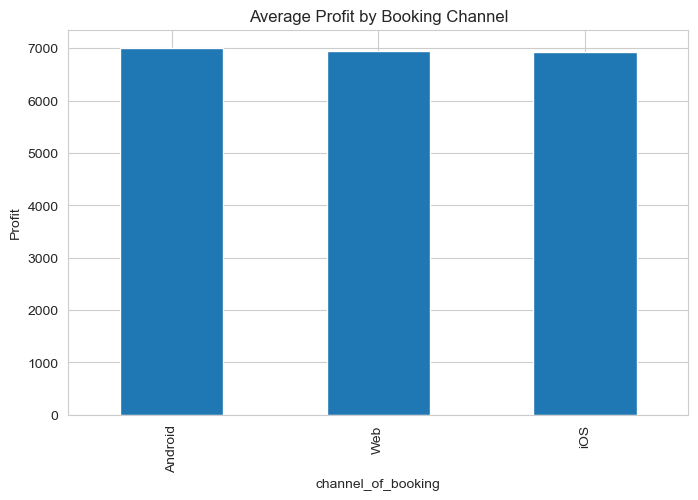

In [33]:
# 10. PROFITABILITY ANALYSIS

df['profit'] = df['selling_price'] - df['costprice']

profit_channel = (
    df.groupby('channel_of_booking')['profit']
      .mean()
      .sort_values(ascending=False)
)

print(profit_channel)

plt.figure(figsize=(8,5))
profit_channel.plot(kind='bar')
plt.title("Average Profit by Booking Channel")
plt.ylabel("Profit")
plt.show()

In [35]:
# 11. REFUND ANALYSIS

refund_analysis = (
    df.groupby('booking_status')
      .agg(
          avg_refund=('refund_amount','mean'),
          total_refund=('refund_amount','sum')
      )
)

print(refund_analysis)

                avg_refund  total_refund
booking_status                          
Cancelled       323.405104  1.963069e+06
Confirmed       320.989241  6.956479e+06
Failed          313.819064  7.086034e+05


In [37]:
# 12. COUPON & CASHBACK ANALYSIS

coupon_analysis = (
    df.groupby('Coupon USed?')
      .agg(
          avg_booking_value=('booking_value','mean'),
          avg_profit=('profit','mean')
      )
)

print(coupon_analysis)

cashback_analysis = (
    df.groupby('booking_status')['cashback']
      .mean()
)

print(cashback_analysis)

              avg_booking_value   avg_profit
Coupon USed?                                
No                 25167.898275  6954.620490
Yes                24744.648699  6996.783788
booking_status
Cancelled    3.945812
Confirmed    3.798910
Failed       3.837453
Name: cashback, dtype: float64


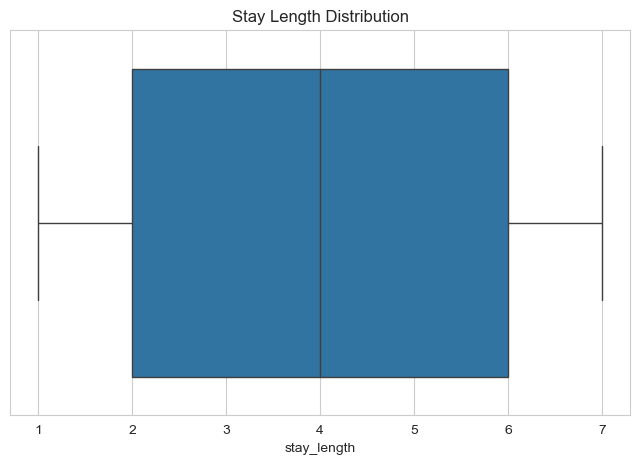

count    24532.000000
mean         4.006848
std          2.001231
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max          7.000000
Name: stay_length, dtype: float64


In [39]:
# 13. STAY LENGTH ANALYSIS

plt.figure(figsize=(8,5))
sns.boxplot(x=df['stay_length'])
plt.title("Stay Length Distribution")
plt.show()

print(df['stay_length'].describe())

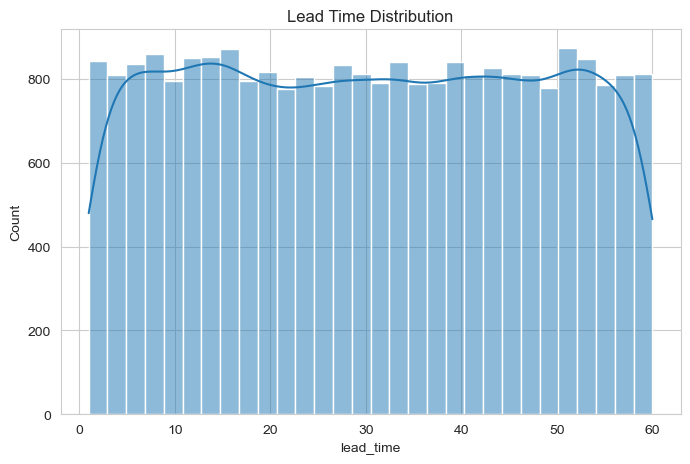

booking_status
Cancelled    30.210732
Confirmed    30.382106
Failed       30.429428
Name: lead_time, dtype: float64


In [41]:
# 14. LEAD TIME ANALYSIS

plt.figure(figsize=(8,5))
sns.histplot(df['lead_time'], bins=30, kde=True)
plt.title("Lead Time Distribution")
plt.show()

lead_analysis = (
    df.groupby('booking_status')['lead_time']
      .mean()
)

print(lead_analysis)

               total_bookings  avg_booking_value   avg_profit
booking_month                                                
April                    4494       25116.494933  6903.393191
August                   2360       26064.735975  7015.156356
December                 2360       23276.987242  6892.764831
February                 2132       27806.446412  7105.279550
January                  2360       23424.240288  7015.708475
July                     2361       25501.593859  7088.978823
June                     2284       24202.785705  7048.947898
March                    2360       27316.317513  6866.408475
May                      2360       23197.152432  6971.131780
November                 2285       25753.245326  6992.634573
October                  2360       24880.617462  6855.972034
September                2284       24635.105197  6872.121716


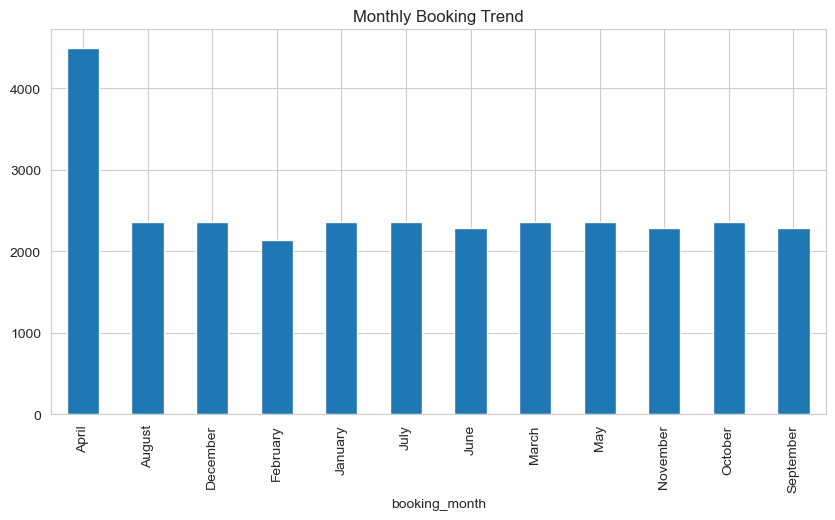

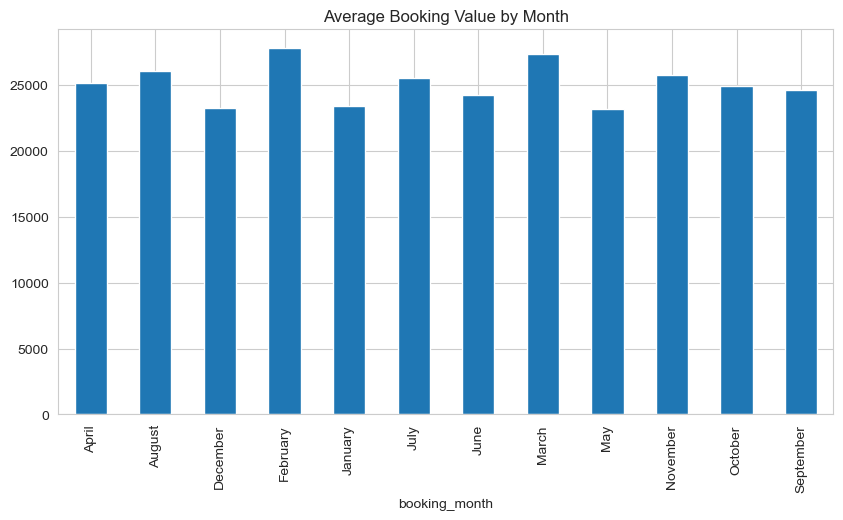

In [43]:
# 15. MONTHLY TREND ANALYSIS

df['booking_month'] = df['booking_date'].dt.month_name()

monthly_analysis = (
    df.groupby('booking_month')
      .agg(
          total_bookings=('customer_id','count'),
          avg_booking_value=('booking_value','mean'),
          avg_profit=('profit','mean')
      )
)

print(monthly_analysis)

monthly_analysis['total_bookings'].plot(
    kind='bar',
    figsize=(10,5)
)
plt.title("Monthly Booking Trend")
plt.show()

monthly_analysis['avg_booking_value'].plot(
    kind='bar',
    figsize=(10,5)
)
plt.title("Average Booking Value by Month")
plt.show()

In [45]:
# 16. CANCELLATION ROOT CAUSE ANALYSIS

cancelled = df[df['booking_status'] == 'Cancelled']

print("Average Lead Time (Cancelled):")
print(cancelled['lead_time'].mean())

print("\nAverage Stay Length (Cancelled):")
print(cancelled['stay_length'].mean())

print("\nCancellation by Room Type")
print(
    pd.crosstab(
        df['room_type'],
        df['booking_status'],
        normalize='index'
    ) * 100
)

print("\nCancellation by Channel")
print(
    pd.crosstab(
        df['channel_of_booking'],
        df['booking_status'],
        normalize='index'
    ) * 100
)

Average Lead Time (Cancelled):
30.210731707317073

Average Stay Length (Cancelled):
4.027317073170732

Cancellation by Room Type
booking_status  Cancelled  Confirmed    Failed
room_type                                     
Deluxe          16.024050  76.312273  7.663676
Standard        23.302320  69.188014  7.509667
Suite           17.979798  74.882155  7.138047

Cancellation by Channel
booking_status      Cancelled  Confirmed    Failed
channel_of_booking                                
Android             20.000000  72.330352  7.669648
Web                 20.333271  72.077638  7.589091
iOS                 20.371199  72.629696  6.999106


In [47]:
# 17. TOP REVENUE GENERATORS

print("\nRevenue by Channel")

print(
    df.groupby('channel_of_booking')['selling_price']
      .sum()
      .sort_values(ascending=False)
)

print("\nRevenue by Room Type")

print(
    df.groupby('room_type')['selling_price']
      .sum()
      .sort_values(ascending=False)
)

print("\nRevenue by Star Rating")

print(
    df.groupby('star_rating')['selling_price']
      .sum()
      .sort_values(ascending=False)
)


Revenue by Channel
channel_of_booking
Web        471636050
Android    282092685
iOS        131415820
Name: selling_price, dtype: int64

Revenue by Room Type
room_type
Standard    489570753
Deluxe      307746286
Suite        87827516
Name: selling_price, dtype: int64

Revenue by Star Rating
star_rating
4    354841176
3    310134032
5    131677093
2     88492254
Name: selling_price, dtype: int64


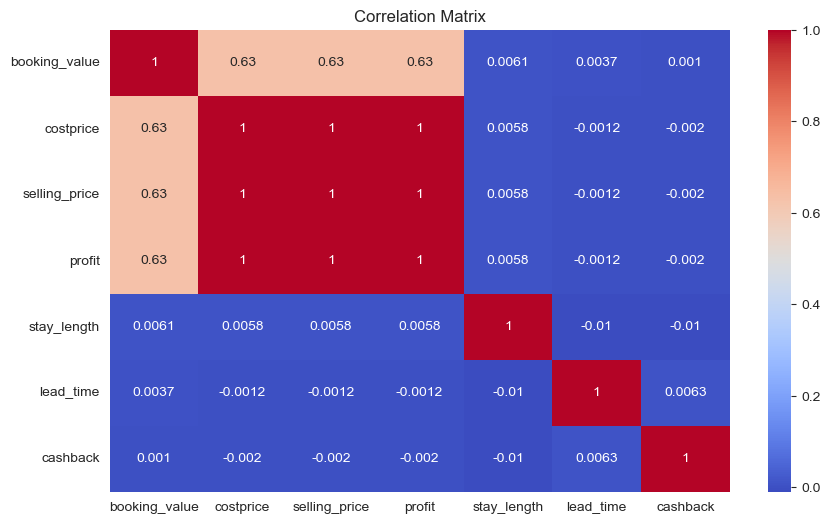

In [49]:
# 18. CORRELATION ANALYSIS

corr_cols = [
    'booking_value',
    'costprice',
    'selling_price',
    'profit',
    'stay_length',
    'lead_time',
    'cashback'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()